In [41]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# For better display in VS Code
%matplotlib inline

print("✓ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4


In [42]:
# UPDATE THIS PATH TO YOUR DATASET LOCATION
filepath = "D:\Ms Projects\Student Depression\student_lifestyle_100k.csv"

# Load the dataset
df = pd.read_csv(filepath)

print("="*80)
print("✓ Dataset loaded successfully!")
print("="*80)
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✓ Dataset loaded successfully!

Dataset Shape: 100,000 rows × 11 columns
Memory Usage: 16.73 MB


In [43]:
# Display first few rows
print("First 5 rows of the dataset:")
print("─"*80)
df.head()

First 5 rows of the dataset:
────────────────────────────────────────────────────────────────────────────────


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [44]:
# Dataset information
print("Dataset Information:")
print("─"*80)
df.info()

Dataset Information:
────────────────────────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [45]:
# Column names
print("\nColumn Names:")
print("─"*80)
for idx, col in enumerate(df.columns, 1):
    print(f"{idx}. {col}")


Column Names:
────────────────────────────────────────────────────────────────────────────────
1. Student_ID
2. Age
3. Gender
4. Department
5. CGPA
6. Sleep_Duration
7. Study_Hours
8. Social_Media_Hours
9. Physical_Activity
10. Stress_Level
11. Depression


In [46]:
# Data types summary
print("\nData Types Summary:")
print("─"*80)
print(df.dtypes.value_counts())
print("\nNumerical columns:", df.select_dtypes(include=[np.number]).columns.tolist())
print("Categorical columns:", df.select_dtypes(include=['object']).columns.tolist())


Data Types Summary:
────────────────────────────────────────────────────────────────────────────────
int64      4
float64    4
object     2
bool       1
Name: count, dtype: int64

Numerical columns: ['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
Categorical columns: ['Gender', 'Department']


In [47]:
# Statistical summary for numerical features
print("Statistical Summary (Numerical Features):")
print("─"*80)
df.describe()

Statistical Summary (Numerical Features):
────────────────────────────────────────────────────────────────────────────────


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [48]:
# Summary for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print("\nCategorical Features Summary:")
    print("─"*80)
    for col in categorical_cols:
        print(f"\n{col}:")
        print(df[col].value_counts())
        print(f"Unique values: {df[col].nunique()}")
        print("-"*40)


Categorical Features Summary:
────────────────────────────────────────────────────────────────────────────────

Gender:
Gender
Male      50120
Female    49880
Name: count, dtype: int64
Unique values: 2
----------------------------------------

Department:
Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64
Unique values: 5
----------------------------------------


In [49]:
# Missing values analysis
print("Missing Values Analysis:")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
    print(f"\n Total columns with missing values: {len(missing_data)}")
else:
    print("✓ No missing values found!")

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Missing Values Analysis:
✓ No missing values found!

Total missing values in dataset: 0


In [50]:
# Duplicate rows check
print("Duplicate Rows Check:")
print("="*80)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates:,}")

if duplicates > 0:
    print(f"Percentage: {(duplicates/len(df))*100:.2f}%")
    print("Recommendation: Consider removing duplicates before modeling")
else:
    print("✓ No duplicates found!")

Duplicate Rows Check:
Number of duplicate rows: 0
✓ No duplicates found!


In [51]:
# Check for constant columns
print("Constant/Near-Constant Columns Check:")
print("="*80)

constant_cols = []
for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

if constant_cols:
    print(f"Constant columns found: {constant_cols}")
    print("Recommendation: These columns provide no information and should be dropped")
else:
    print("✓ No constant columns found!")

Constant/Near-Constant Columns Check:
✓ No constant columns found!


In [52]:
# Identify target column
possible_target_names = ['Depression', 'Depression_Status', 'depression', 'target', 'label']
target_col = None

for name in possible_target_names:
    if name in df.columns:
        target_col = name
        break

if target_col is None:
    print("Warning: Could not automatically identify target column")
    print("Available columns:", df.columns.tolist())
    # Manually set it here if needed:
    # target_col = 'your_target_column_name'
else:
    print(f"✓ Target Variable Identified: '{target_col}'")

✓ Target Variable Identified: 'Depression'


In [53]:
# Target variable distribution
if target_col:
    print("="*80)
    print(f" TARGET VARIABLE ANALYSIS: '{target_col}'")
    print("="*80)
    
    # Class distribution
    print("\nClass Distribution (Count):")
    print("─"*40)
    class_dist = df[target_col].value_counts()
    print(class_dist)
    
    # Percentages
    print("\nClass Distribution (Percentage):")
    print("─"*40)
    class_pct = df[target_col].value_counts(normalize=True) * 100
    print(class_pct)
    
    # Class imbalance ratio
    imbalance_ratio = class_dist.max() / class_dist.min()
    print(f"\n Class Imbalance Ratio: {imbalance_ratio:.2f}")
    
    if imbalance_ratio > 1.5:
        print("\n  CLASS IMBALANCE DETECTED!")
        
    else:
        print("\n✓ Classes are relatively balanced ")
    
    # Save these numbers for your proposal!
    print("\n" + "="*80)
    
    for category, count in class_dist.items():
        pct = (count / len(df)) * 100
        print(f"  {category}: {count:,} students ({pct:.1f}%)")

 TARGET VARIABLE ANALYSIS: 'Depression'

Class Distribution (Count):
────────────────────────────────────────
Depression
False    89938
True     10062
Name: count, dtype: int64

Class Distribution (Percentage):
────────────────────────────────────────
Depression
False    89.938
True     10.062
Name: proportion, dtype: float64

 Class Imbalance Ratio: 8.94

  CLASS IMBALANCE DETECTED!

  False: 89,938 students (89.9%)
  True: 10,062 students (10.1%)


✓ Saved: target_distribution.png


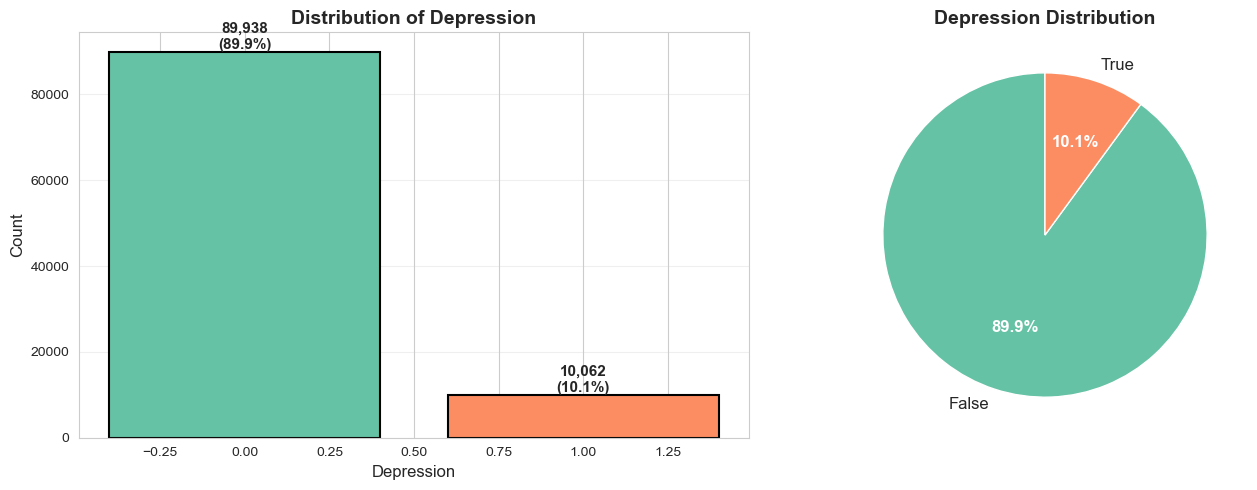

In [54]:
# Visualize target variable distribution
if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    class_dist = df[target_col].value_counts()
    colors_bar = ['#66c2a5', '#fc8d62']
    axes[0].bar(class_dist.index, class_dist.values, color=colors_bar, edgecolor='black', linewidth=1.5)
    axes[0].set_title(f'Distribution of {target_col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(target_col, fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (category, value) in enumerate(class_dist.items()):
        axes[0].text(i, value, f'{value:,}\n({value/len(df)*100:.1f}%)', 
                    ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Pie chart
    colors_pie = ['#66c2a5', '#fc8d62']
    wedges, texts, autotexts = axes[1].pie(class_dist, labels=class_dist.index, autopct='%1.1f%%', 
                                            startangle=90, colors=colors_pie, textprops={'fontsize': 12})
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    axes[1].set_title(f'{target_col} Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: target_distribution.png")
    plt.show()

In [55]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target if it's numerical
if target_col and target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("="*80)
print(f"NUMERICAL FEATURES ({len(numerical_cols)} features)")
print("="*80)
print("\nFeatures:", numerical_cols)

NUMERICAL FEATURES (8 features)

Features: ['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


✓ Saved: numerical_distributions.png


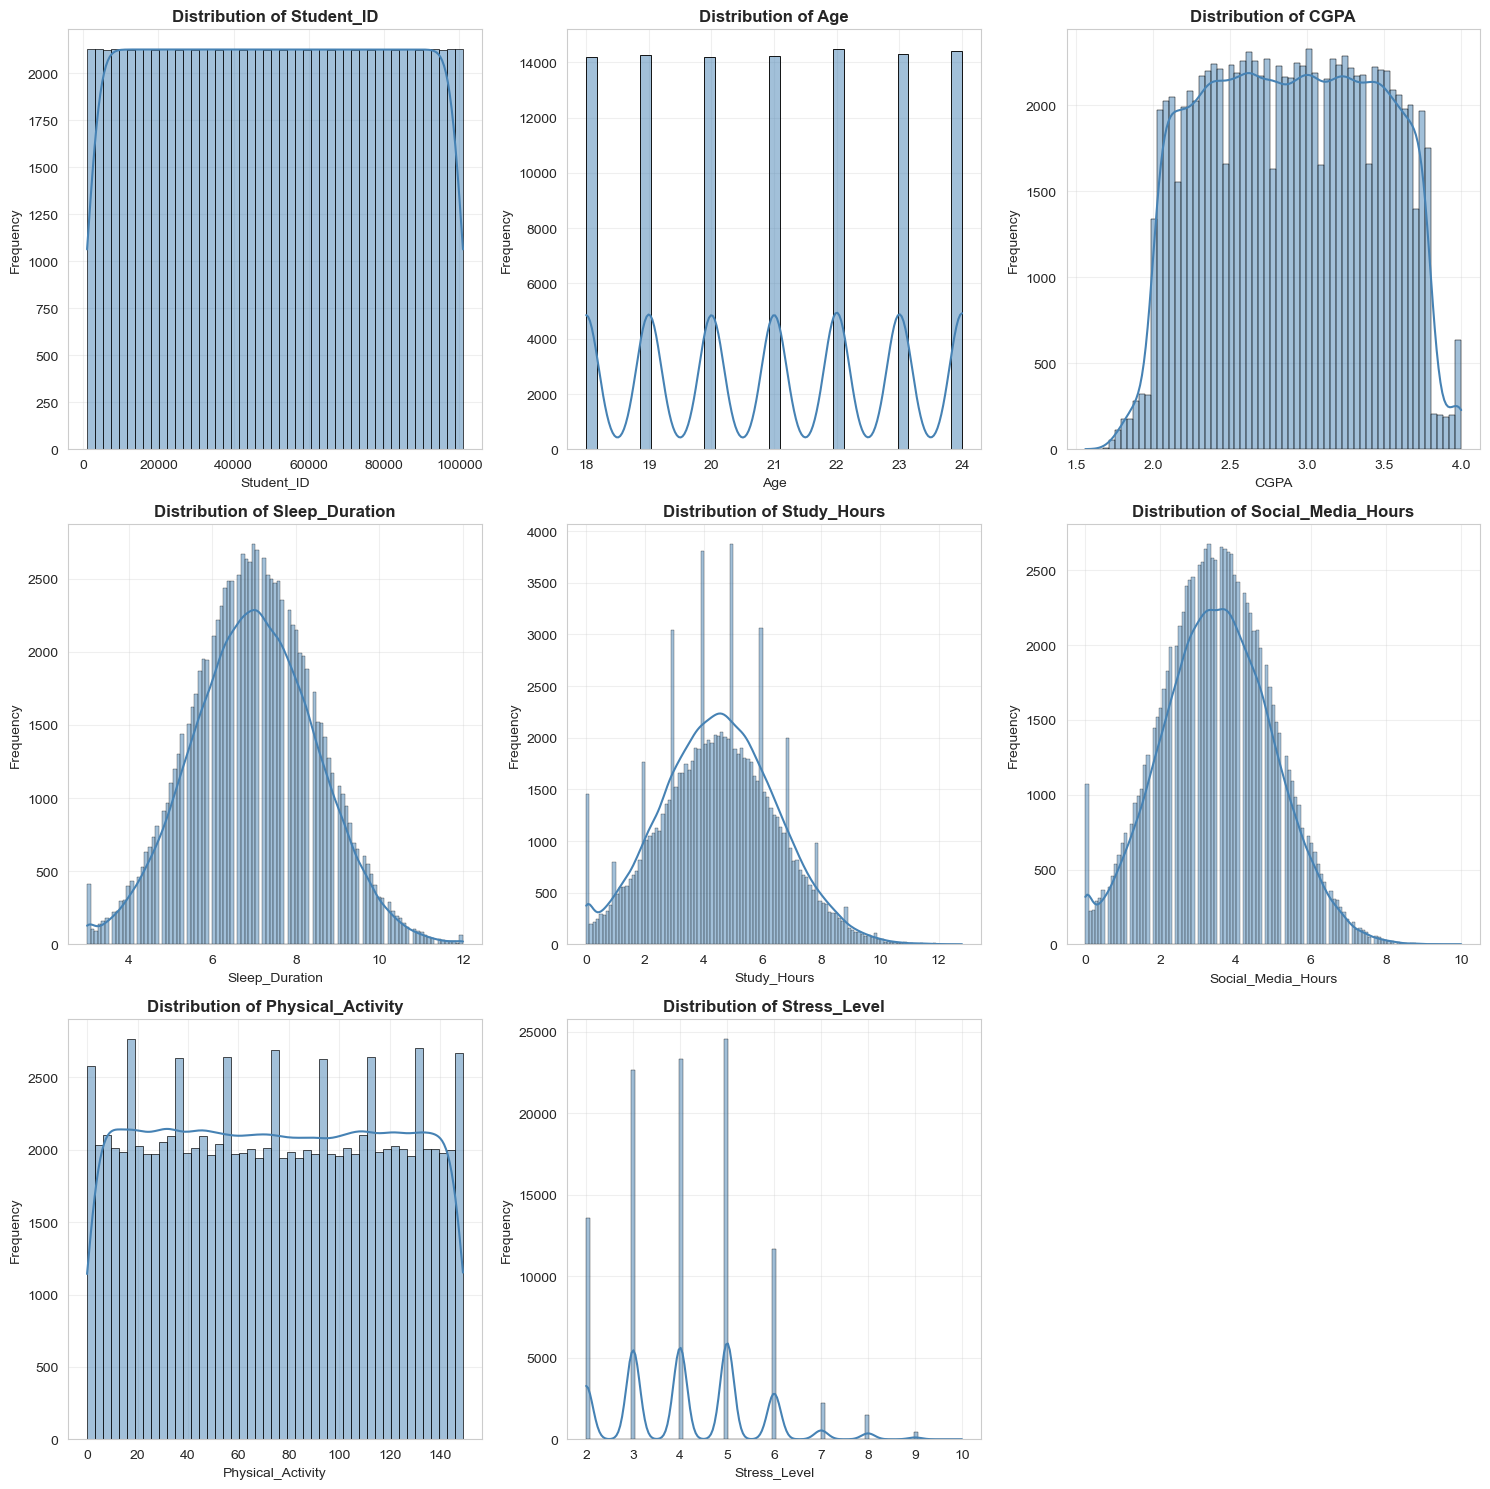

In [56]:
# Visualize distributions of numerical features
if len(numerical_cols) > 0:
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(alpha=0.3)
    
    # Hide extra subplots
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('numerical_distributions.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: numerical_distributions.png")
    plt.show()

✓ Saved: numerical_by_target.png


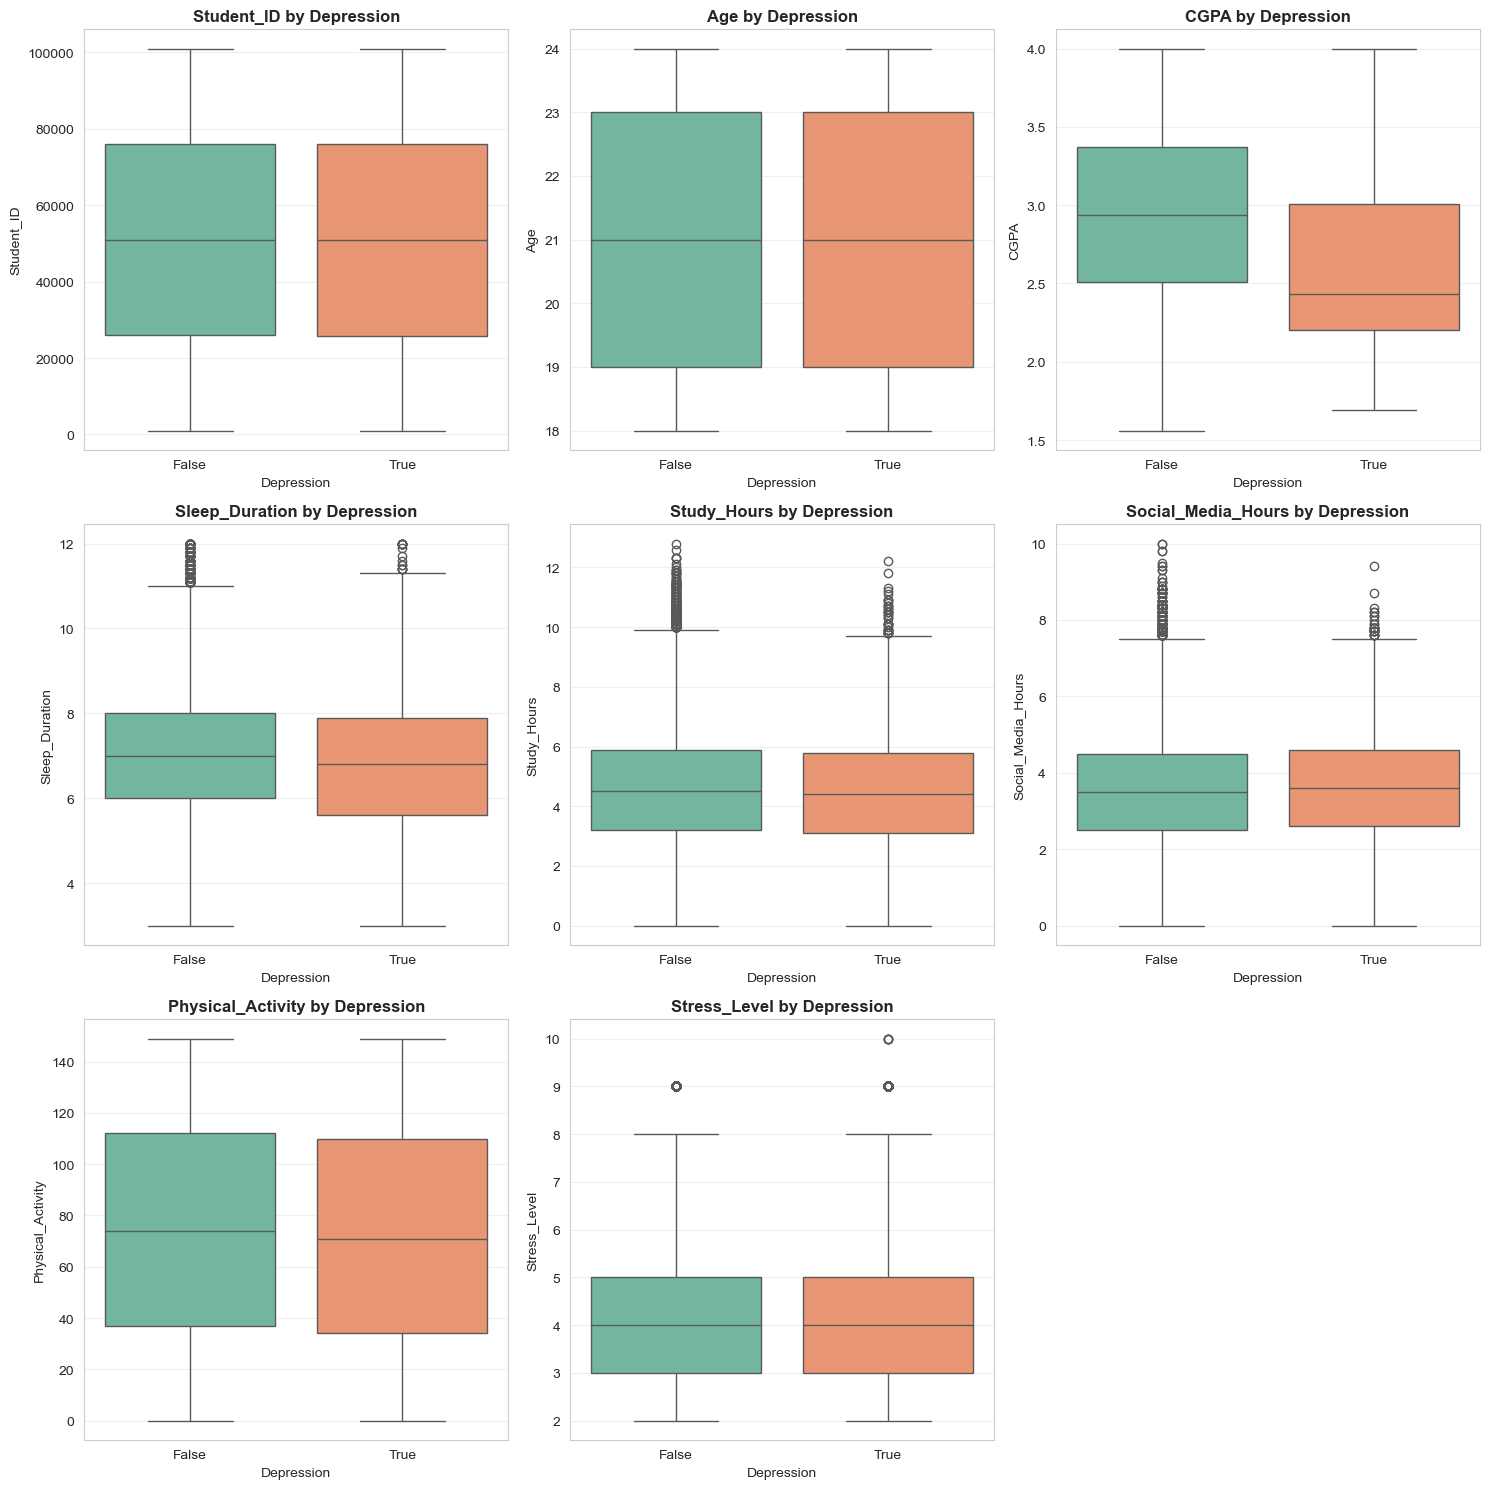

In [57]:
# Box plots: Numerical features by Target variable
if target_col and len(numerical_cols) > 0:
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        sns.boxplot(data=df, x=target_col, y=col, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'{col} by {target_col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel(target_col, fontsize=10)
        axes[idx].set_ylabel(col, fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
    
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('numerical_by_target.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: numerical_by_target.png")
    plt.show()

In [58]:
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target if it's categorical
if target_col and target_col in categorical_cols:
    categorical_cols.remove(target_col)

print("="*80)
print(f"CATEGORICAL FEATURES ({len(categorical_cols)} features)")
print("="*80)
print("\nFeatures:", categorical_cols)

CATEGORICAL FEATURES (2 features)

Features: ['Gender', 'Department']


In [59]:
# Unique values count
if len(categorical_cols) > 0:
    print("\nUnique Values Count:")
    print("="*80)
    
    for col in categorical_cols:
        unique_count = df[col].nunique()
        print(f"\n{col}: {unique_count} unique values")
        if unique_count <= 10:
            print(f"  Values: {df[col].unique().tolist()}")
            print(f"  Distribution:")
            print(df[col].value_counts())


Unique Values Count:

Gender: 2 unique values
  Values: ['Female', 'Male']
  Distribution:
Gender
Male      50120
Female    49880
Name: count, dtype: int64

Department: 5 unique values
  Values: ['Science', 'Engineering', 'Medical', 'Arts', 'Business']
  Distribution:
Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64


✓ Saved: categorical_gender.png


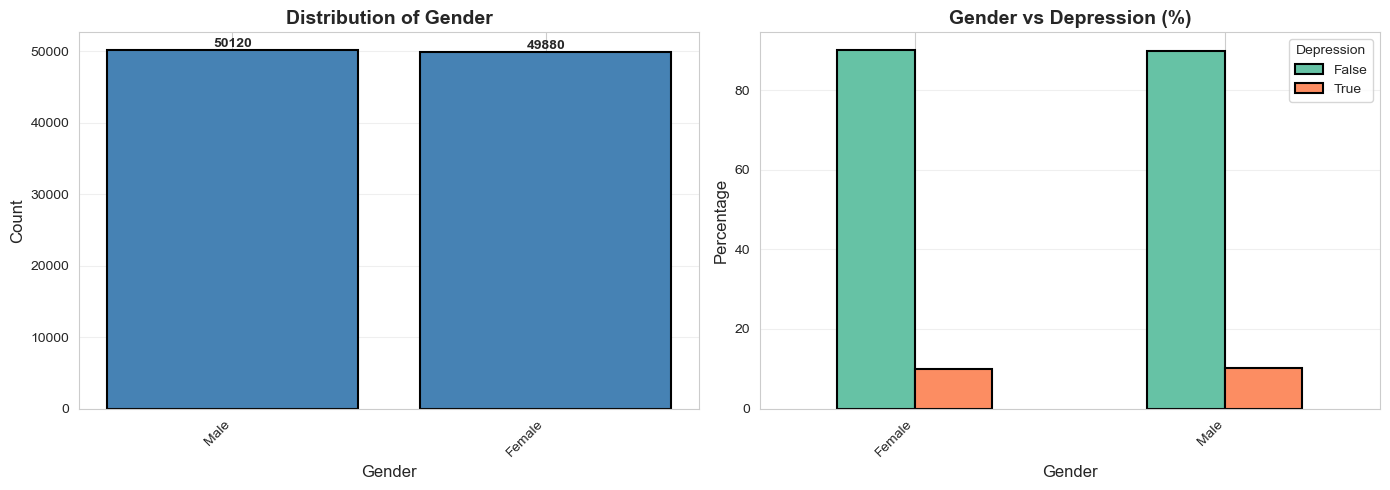

✓ Saved: categorical_department.png


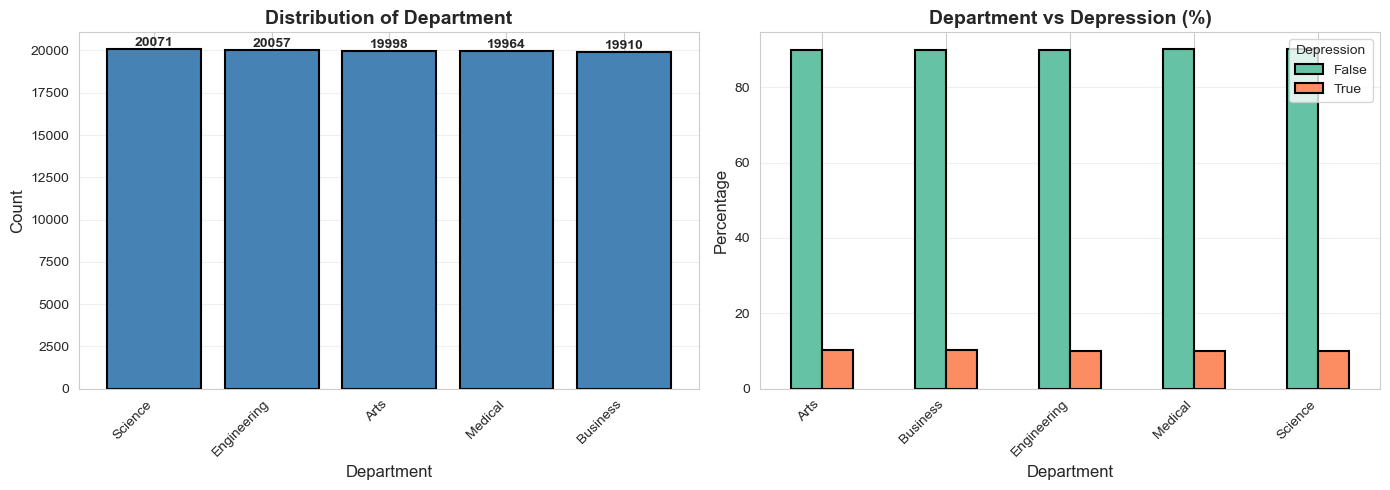

In [60]:
# Visualize categorical features (only if <=10 unique values)
if len(categorical_cols) > 0:
    for col in categorical_cols:
        unique_count = df[col].nunique()
        
        if unique_count <= 10:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Count plot
            value_counts = df[col].value_counts()
            axes[0].bar(range(len(value_counts)), value_counts.values, 
                       color='steelblue', edgecolor='black', linewidth=1.5)
            axes[0].set_xticks(range(len(value_counts)))
            axes[0].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[0].set_title(f'Distribution of {col}', fontweight='bold', fontsize=14)
            axes[0].set_xlabel(col, fontsize=12)
            axes[0].set_ylabel('Count', fontsize=12)
            axes[0].grid(axis='y', alpha=0.3)
            
            # Add value labels
            for i, v in enumerate(value_counts.values):
                axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
            
            # Grouped by target (if target exists)
            if target_col:
                crosstab = pd.crosstab(df[col], df[target_col], normalize='index') * 100
                crosstab.plot(kind='bar', ax=axes[1], color=['#66c2a5', '#fc8d62'], 
                             edgecolor='black', linewidth=1.5)
                axes[1].set_title(f'{col} vs {target_col} (%)', fontweight='bold', fontsize=14)
                axes[1].set_xlabel(col, fontsize=12)
                axes[1].set_ylabel('Percentage', fontsize=12)
                axes[1].legend(title=target_col, loc='best')
                axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
                axes[1].grid(axis='y', alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(f'categorical_{col.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
            print(f"✓ Saved: categorical_{col.lower().replace(' ', '_')}.png")
            plt.show()

In [61]:
# Prepare data for correlation analysis
df_encoded = df.copy()

# Encode target variable if categorical
if target_col and df[target_col].dtype == 'object':
    # Try common encodings
    if 'Yes' in df[target_col].values or 'No' in df[target_col].values:
        df_encoded[target_col] = df_encoded[target_col].map({'Yes': 1, 'No': 0})
    else:
        unique_vals = df[target_col].unique()
        df_encoded[target_col] = df[target_col].map({unique_vals[0]: 0, unique_vals[1]: 1})

# Encode other categorical variables for correlation
for col in df_encoded.select_dtypes(include=['object']).columns:
    if col != target_col:
        # Simple label encoding
        df_encoded[col] = pd.Categorical(df_encoded[col]).codes

# Get correlation matrix
numerical_df = df_encoded.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

print("="*80)
print("CORRELATION MATRIX")
print("="*80)
print(corr_matrix)

CORRELATION MATRIX
                    Student_ID       Age    Gender  Department      CGPA  \
Student_ID            1.000000  0.000855  0.002563   -0.000737 -0.001592   
Age                   0.000855  1.000000 -0.003105   -0.002833  0.003248   
Gender                0.002563 -0.003105  1.000000   -0.000399 -0.005163   
Department           -0.000737 -0.002833 -0.000399    1.000000 -0.002944   
CGPA                 -0.001592  0.003248 -0.005163   -0.002944  1.000000   
Sleep_Duration        0.002824  0.001357  0.002505    0.000946  0.015386   
Study_Hours           0.001945 -0.003808  0.000641   -0.003370  0.099534   
Social_Media_Hours   -0.002281 -0.000436  0.001473    0.002292 -0.087998   
Physical_Activity     0.003315 -0.003676  0.004258   -0.006963  0.004766   
Stress_Level         -0.005230  0.002999  0.001154    0.002520 -0.012287   

                    Sleep_Duration  Study_Hours  Social_Media_Hours  \
Student_ID                0.002824     0.001945           -0.002281   
Ag

In [62]:
# Correlation with target variable
if target_col and target_col in corr_matrix.columns:
    print("\n" + "="*80)
    print(f"CORRELATION WITH TARGET: '{target_col}'")
    print("="*80)
    
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
    
    print("\nAll features (sorted by absolute correlation):")
    print("─"*60)
    for feature, corr_val in target_corr.items():
        strength = "STRONG" if abs(corr_val) > 0.5 else "MODERATE" if abs(corr_val) > 0.3 else "WEAK"
        direction = "(positive)" if corr_val > 0 else "(negative)"
        print(f"  {feature:30s}: {corr_val:7.3f} {direction:12s} [{strength}]")
    
    # Strong correlations
    print("\n" + "="*80)
    print("STRONG PREDICTORS ")
    print("="*80)
    strong_corr = target_corr[abs(target_corr) > 0.3]
    
    if len(strong_corr) > 0:
        for idx, (feature, corr_val) in enumerate(strong_corr.items(), 1):
            print(f"{idx}. {feature}: r = {corr_val:.3f}")
    else:
        print("  No strong correlations found (consider features with |r| > 0.2)")
        moderate_corr = target_corr[abs(target_corr) > 0.2]
        if len(moderate_corr) > 0:
            print("\nModerate correlations (|r| > 0.2):")
            for feature, corr_val in moderate_corr.items():
                print(f"  - {feature}: {corr_val:.3f}")

✓ Saved: correlation_heatmap.png


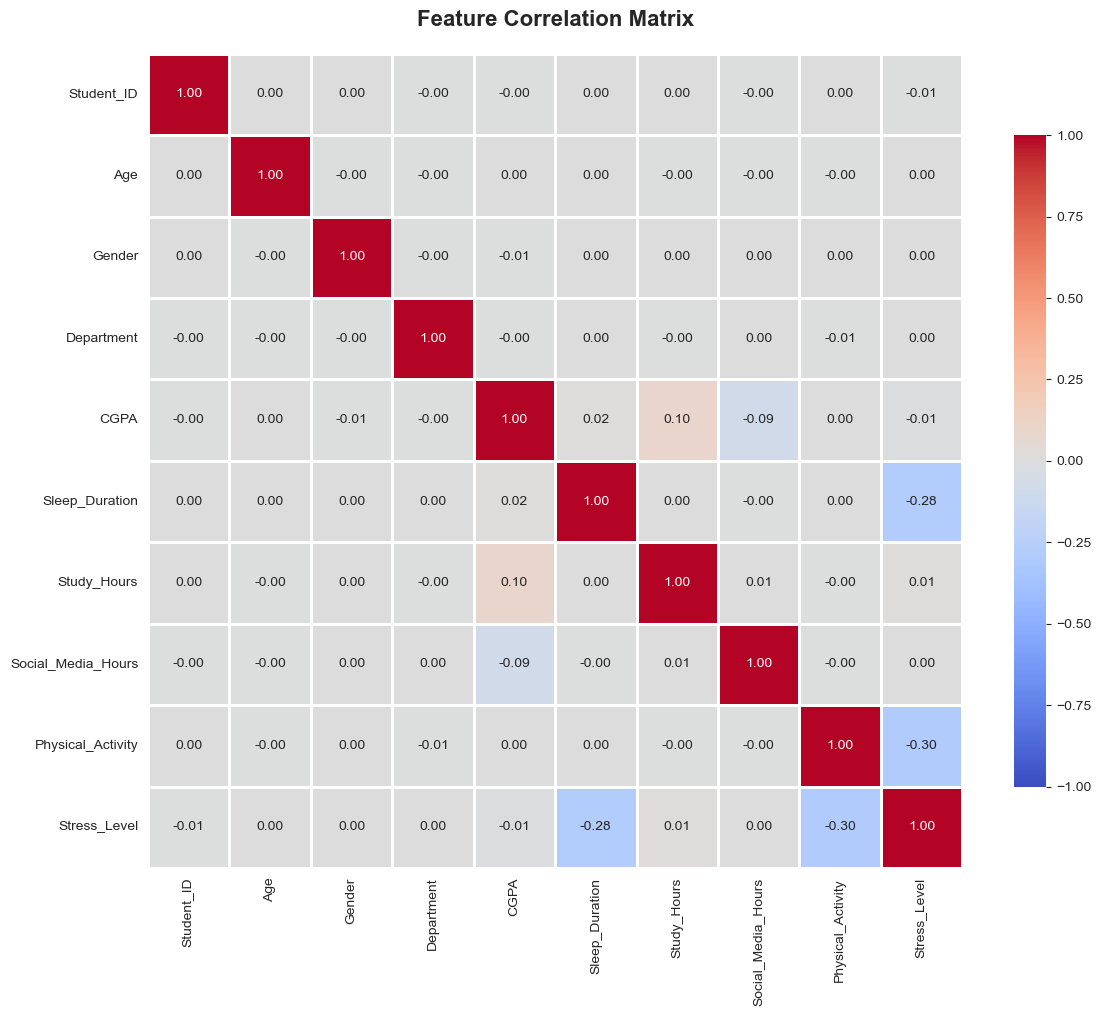

In [63]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: correlation_heatmap.png")
plt.show()

In [64]:
# Focused heatmap: Top correlated features with target
if target_col and target_col in corr_matrix.columns:
    # Get top 8 features most correlated with target
    target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
    top_features = target_corr.head(min(8, len(target_corr))).index.tolist()
    top_features.append(target_col)
    
    # Create focused correlation matrix
    focused_corr = corr_matrix.loc[top_features, top_features]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(focused_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title(f'Top Predictors Correlation with {target_col}', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('top_predictors_correlation.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: top_predictors_correlation.png")
    plt.show()

In [ ]:
print("="*80)
print("FEATURE ENGINEERING & PREPROCESSING RECOMMENDATIONS")
print("="*80)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if target_col in categorical_cols:
    categorical_cols.remove(target_col)
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("\n✓ Features to Use in ML Models:")
print("─"*60)
print(f"  Numerical features ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"    - {col}")
print(f"\n  Categorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"    - {col}")

print("\nPre-processing Pipeline:")
print("─"*60)
print("\n1. DATA CLEANING:")
if df.isnull().sum().sum() > 0:
    print("   - Handle missing values (imputation)")
if df.duplicated().sum() > 0:
    print("   - Remove duplicate rows")
print("   - Check for outliers and handle if necessary")

print("\n2. ENCODING CATEGORICAL VARIABLES:")
if len(categorical_cols) > 0:
    print("   - Binary encoding for binary features (e.g., Gender: Male/Female → 0/1)")
    print("   - Ordinal encoding for ordinal features (e.g., Pressure: Low/Medium/High → 0/1/2)")
    print("   - One-Hot encoding for nominal features (if needed)")

print("\n3. FEATURE SCALING:")
if len(numerical_cols) > 0:
    print("   - Use StandardScaler or MinMaxScaler for numerical features")
    print("   - Critical for: SVM, KNN, Neural Networks")
    print("   - Optional for: Tree-based models (Random Forest, Decision Tree)")

print("\n4. HANDLE CLASS IMBALANCE:")
if target_col:
    class_dist = df[target_col].value_counts()
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 1.5:
        print("   - Use SMOTE for oversampling minority class")
        print("   - Or use class_weight='balanced' in models")
        print("   - Use stratified train-test split")
    else:
        print("   - Classes are balanced - no special handling needed")

print("\n5. FEATURE SELECTION (Optional):")
print("   - Consider removing low-correlation features (|r| < 0.1)")
print("   - Check for multicollinearity (VIF analysis)")
print("   - Use feature importance from tree-based models")


💡 FEATURE ENGINEERING & PREPROCESSING RECOMMENDATIONS

✓ Features to Use in ML Models:
────────────────────────────────────────────────────────────
  Numerical features (8):
    - Student_ID
    - Age
    - CGPA
    - Sleep_Duration
    - Study_Hours
    - Social_Media_Hours
    - Physical_Activity
    - Stress_Level

  Categorical features (2):
    - Gender
    - Department

Pre-processing Pipeline:
────────────────────────────────────────────────────────────

1. DATA CLEANING:
   - Check for outliers and handle if necessary

2. ENCODING CATEGORICAL VARIABLES:
   - Binary encoding for binary features (e.g., Gender: Male/Female → 0/1)
   - Ordinal encoding for ordinal features (e.g., Pressure: Low/Medium/High → 0/1/2)
   - One-Hot encoding for nominal features (if needed)

3. FEATURE SCALING:
   - Use StandardScaler or MinMaxScaler for numerical features
   - Critical for: SVM, KNN, Neural Networks
   - Optional for: Tree-based models (Random Forest, Decision Tree)

4. HANDLE CLASS IMB

In [66]:


summary = f"""
╔═══════════════════════════════════════════════════════════════════════════╗
║              STUDENT DEPRESSION DATASET - EXPLORATION SUMMARY             ║
╚═══════════════════════════════════════════════════════════════════════════╝

DATASET OVERVIEW:
{'─'*79}
Total Samples:        {df.shape[0]:,}
Total Features:       {df.shape[1]}
Memory Usage:         {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB
Numerical Features:   {len(df.select_dtypes(include=[np.number]).columns)}
Categorical Features: {len(df.select_dtypes(include=['object']).columns)}

"""

if target_col:
    class_dist = df[target_col].value_counts()
    class_pct = (df[target_col].value_counts(normalize=True) * 100)
    imbalance_ratio = class_dist.max() / class_dist.min()
    
    summary += f"""
TARGET VARIABLE: {target_col}
{'─'*79}
"""
    for category, count in class_dist.items():
        pct = (count / len(df)) * 100
        summary += f"{category}: {count:,} ({pct:.1f}%)\n"
    
    summary += f"""
Class Imbalance Ratio: {imbalance_ratio:.2f}
Status: {'Balanced' if imbalance_ratio < 1.5 else 'Imbalanced - Use SMOTE/Class Weights'}
"""


# Phase 1 — Data Preprocessing & Semi-Supervised Split

## Step 1: Feature Engineering

In [67]:

df_model = df.copy()

# 1a. Drop Student_ID — it is a row identifier, not a predictor
df_model = df_model.drop(columns=['Student_ID'])
print(f"✓ Dropped 'Student_ID'. Remaining columns: {df_model.shape[1]}")

# 1b. Encode the target variable: True → 1, False → 0
df_model['Depression'] = df_model['Depression'].astype(int)
print(f"✓ Target encoded  →  0: {(df_model['Depression']==0).sum():,}  |  1: {(df_model['Depression']==1).sum():,}")

# 1c. Encode Gender: Male → 1, Female → 0
df_model['Gender'] = df_model['Gender'].map({'Male': 1, 'Female': 0})
print(f"✓ Gender encoded  →  Male=1: {(df_model['Gender']==1).sum():,}  |  Female=0: {(df_model['Gender']==0).sum():,}")

# 1d. One-hot encode Department (drop first to avoid multicollinearity)
df_model = pd.get_dummies(df_model, columns=['Department'], drop_first=True)
dept_cols = [c for c in df_model.columns if c.startswith('Department_')]
print(f"✓ Department encoded → new columns: {dept_cols}")



✓ Dropped 'Student_ID'. Remaining columns: 10
✓ Target encoded  →  0: 89,938  |  1: 10,062
✓ Gender encoded  →  Male=1: 50,120  |  Female=0: 49,880
✓ Department encoded → new columns: ['Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science']


## Step 2: Create the 10% Labeled / 90% Unlabeled Split

In [68]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Depression'])
y = df_model['Depression']


X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)


X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(
    X_trainval, y_trainval, test_size=0.90, stratify=y_trainval, random_state=42
)

print("="*60)
print("SEMI-SUPERVISED DATA SPLIT SUMMARY")
print("="*60)

total = len(X)
sets = {
    "Labeled (train)"  : (X_labeled,   y_labeled),
    "Unlabeled (pool)" : (X_unlabeled, y_unlabeled),
    "Test (held-out)"  : (X_test,      y_test),
}

for name, (Xs, ys) in sets.items():
    n         = len(Xs)
    pct       = n / total * 100
    dep_rate  = ys.mean() * 100
    print(f"\n{name}")
    print(f"  Samples       : {n:>7,}  ({pct:.1f}% of full data)")
    print(f"  Depressed (1) : {ys.sum():>7,}  ({dep_rate:.1f}%)")
    print(f"  Not dep.  (0) : {(ys==0).sum():>7,}  ({100-dep_rate:.1f}%)")

print("\n" + "="*60)
print(f"Total samples : {total:,}")
print(f"Features      : {X.shape[1]}")
print("="*60)



SEMI-SUPERVISED DATA SPLIT SUMMARY

Labeled (train)
  Samples       :   9,000  (9.0% of full data)
  Depressed (1) :     906  (10.1%)
  Not dep.  (0) :   8,094  (89.9%)

Unlabeled (pool)
  Samples       :  81,000  (81.0% of full data)
  Depressed (1) :   8,150  (10.1%)
  Not dep.  (0) :  72,850  (89.9%)

Test (held-out)
  Samples       :  10,000  (10.0% of full data)
  Depressed (1) :   1,006  (10.1%)
  Not dep.  (0) :   8,994  (89.9%)

Total samples : 100,000
Features      : 12


## Step 3: Scale Features

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on labeled training data — never on unlabeled or test set
X_labeled_scaled   = scaler.fit_transform(X_labeled)
X_unlabeled_scaled = scaler.transform(X_unlabeled)
X_test_scaled      = scaler.transform(X_test)

# ── Verification ─────────────────────────────────────────────────────────────
print("=" * 60)
print("FEATURE SCALING SUMMARY  (StandardScaler)")
print("=" * 60)

print(f"\n{'Set':<20} {'Shape':<20} {'Mean':>8} {'Std':>8}")
print("-" * 60)
for name, arr in [
    ("Labeled (train)",   X_labeled_scaled),
    ("Unlabeled (pool)",  X_unlabeled_scaled),
    ("Test (held-out)",   X_test_scaled),
]:
    print(f"{name:<20} {str(arr.shape):<20} {arr.mean():>+.4f}   {arr.std():.4f}")


FEATURE SCALING SUMMARY  (StandardScaler)

Set                  Shape                    Mean      Std
------------------------------------------------------------
Labeled (train)      (9000, 12)           -0.0000   1.0000
Unlabeled (pool)     (81000, 12)          -0.0043   0.9999
Test (held-out)      (10000, 12)          -0.0002   1.0020


## Step 4: Handle Class Imbalance with SMOTE

In [70]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY on the labeled training set 
smote = SMOTE(random_state=42)
X_labeled_res, y_labeled_res = smote.fit_resample(X_labeled_scaled, y_labeled)

print("=" * 60)
print("SMOTE OVERSAMPLING SUMMARY")
print("=" * 60)

print("\nBefore SMOTE (labeled set):")
print(f"  Total samples    : {len(y_labeled):,}")
print(f"  Depressed   (1)  : {y_labeled.sum():,}  ({y_labeled.mean()*100:.1f}%)")
print(f"  Not dep.    (0)  : {(y_labeled==0).sum():,}  ({(1-y_labeled.mean())*100:.1f}%)")

print("\nAfter SMOTE (resampled labeled set):")
import numpy as np
unique, counts = np.unique(y_labeled_res, return_counts=True)
total_res = len(y_labeled_res)
for cls, cnt in zip(unique, counts):
    label = "Depressed (1)" if cls == 1 else "Not dep.  (0)"
    print(f"  {label}  : {cnt:,}  ({cnt/total_res*100:.1f}%)")
print(f"  Total samples    : {total_res:,}")

print("\n" + "=" * 60)
print(f"Synthetic samples added : {total_res - len(y_labeled):,}")
print(f"Imbalance ratio before  : {(y_labeled==0).sum() / y_labeled.sum():.2f}")
after_ratio = counts[0] / counts[1]
print(f"Imbalance ratio after   : {after_ratio:.2f}")
print("=" * 60)



SMOTE OVERSAMPLING SUMMARY

Before SMOTE (labeled set):
  Total samples    : 9,000
  Depressed   (1)  : 906  (10.1%)
  Not dep.    (0)  : 8,094  (89.9%)

After SMOTE (resampled labeled set):
  Not dep.  (0)  : 8,094  (50.0%)
  Depressed (1)  : 8,094  (50.0%)
  Total samples    : 16,188

Synthetic samples added : 7,188
Imbalance ratio before  : 8.93
Imbalance ratio after   : 1.00


## Phase 2 — Self-Training Pipeline

## Step 5: Train the Base Supervised Model

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, roc_auc_score

# Train base model on SMOTE-resampled labeled set only
base_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
base_model.fit(X_labeled_res, y_labeled_res)

# Evaluate on held-out test set
y_pred_base  = base_model.predict(X_test_scaled)
y_proba_base = base_model.predict_proba(X_test_scaled)[:, 1]

f1_base  = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base)

# ── Summary ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("BASE MODEL RESULTS")
print("=" * 60)
print(f"\n  F1-Score : {f1_base:.4f}")
print(f"  ROC-AUC  : {auc_base:.4f}")
print("\nDetailed Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred_base, target_names=["Not Depressed", "Depressed"]))
print("=" * 60)



BASE MODEL RESULTS

  F1-Score : 0.1602
  ROC-AUC  : 0.6766

Detailed Classification Report:
------------------------------------------------------------
               precision    recall  f1-score   support

Not Depressed       0.91      0.96      0.93      8994
    Depressed       0.24      0.12      0.16      1006

     accuracy                           0.87     10000
    macro avg       0.57      0.54      0.55     10000
 weighted avg       0.84      0.87      0.85     10000



## Step 6: Iterative Self-Training Loop (θ ≥ 0.90, max 5 iterations)

In [72]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

CONFIDENCE_THRESHOLD = 0.90
MAX_ITERATIONS       = 5

# Start with the SMOTE-resampled labeled set
X_train_ssl = X_labeled_res.copy()
y_train_ssl = y_labeled_res.copy()
X_pool      = X_unlabeled_scaled.copy()

history = []  # track progress each iteration

print("=" * 65)
print("SELF-TRAINING LOOP")
print(f"Confidence threshold : {CONFIDENCE_THRESHOLD}")
print(f"Max iterations       : {MAX_ITERATIONS}")
print("=" * 65)

for iteration in range(1, MAX_ITERATIONS + 1):

    # 1. Train on current labeled set
    ssl_model = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    ssl_model.fit(X_train_ssl, y_train_ssl)

    # 2. Predict probabilities on unlabeled pool
    proba        = ssl_model.predict_proba(X_pool)
    max_proba    = proba.max(axis=1)
    pseudo_labels = ssl_model.predict(X_pool)

    # 3. Select only high-confidence predictions (θ ≥ 0.90)
    confident_mask = max_proba >= CONFIDENCE_THRESHOLD
    n_added        = confident_mask.sum()

    # 4. Evaluate on test set this iteration
    y_pred_iter = ssl_model.predict(X_test_scaled)
    f1_iter     = f1_score(y_test, y_pred_iter)

    history.append({
        'iteration'   : iteration,
        'train_size'  : len(X_train_ssl),
        'pool_size'   : len(X_pool),
        'n_added'     : n_added,
        'f1'          : f1_iter,
    })

    print(f"\nIteration {iteration}:")
    print(f"  Training set size : {len(X_train_ssl):,}")
    print(f"  Pool size         : {len(X_pool):,}")
    print(f"  High-conf samples : {n_added:,}  (≥ {CONFIDENCE_THRESHOLD})")
    print(f"  F1-Score (test)   : {f1_iter:.4f}")

    # 5. Stop early if no confident samples remain
    if n_added == 0:
        print("\n  No new confident samples — stopping early.")
        break

    # 6. Merge confident pseudo-labeled samples into training set
    X_train_ssl = np.vstack([X_train_ssl, X_pool[confident_mask]])
    y_train_ssl = np.concatenate([y_train_ssl, pseudo_labels[confident_mask]])

    # 7. Remove added samples from pool
    X_pool = X_pool[~confident_mask]

print("\n" + "=" * 65)
print("SELF-TRAINING COMPLETE")
print("=" * 65)
print(f"\n  Final training set size : {len(X_train_ssl):,}")
print(f"  Remaining pool size     : {len(X_pool):,}")
print(f"  Best F1-Score           : {max(h['f1'] for h in history):.4f}")
print(f"  Baseline F1-Score       : {f1_base:.4f}")
improvement = max(h['f1'] for h in history) - f1_base
print(f"  Improvement over base   : {improvement:+.4f}")


SELF-TRAINING LOOP
Confidence threshold : 0.9
Max iterations       : 5

Iteration 1:
  Training set size : 16,188
  Pool size         : 81,000
  High-conf samples : 24,296  (≥ 0.9)
  F1-Score (test)   : 0.1602

Iteration 2:
  Training set size : 40,484
  Pool size         : 56,704
  High-conf samples : 20,812  (≥ 0.9)
  F1-Score (test)   : 0.1522

Iteration 3:
  Training set size : 61,296
  Pool size         : 35,892
  High-conf samples : 8,426  (≥ 0.9)
  F1-Score (test)   : 0.1508

Iteration 4:
  Training set size : 69,722
  Pool size         : 27,466
  High-conf samples : 4,540  (≥ 0.9)
  F1-Score (test)   : 0.1541

Iteration 5:
  Training set size : 74,262
  Pool size         : 22,926
  High-conf samples : 3,073  (≥ 0.9)
  F1-Score (test)   : 0.1435

SELF-TRAINING COMPLETE

  Final training set size : 77,335
  Remaining pool size     : 19,853
  Best F1-Score           : 0.1602
  Baseline F1-Score       : 0.1602
  Improvement over base   : +0.0000


## Phase 3 — Evaluation

## Step 7: Final Evaluation on Held-Out Test Set

FINAL SSL MODEL — TEST SET EVALUATION

  F1-Score  : 0.1435
  ROC-AUC   : 0.6819
  Precision : 0.2512
  Recall    : 0.1004

Detailed Classification Report:
-----------------------------------------------------------------
               precision    recall  f1-score   support

Not Depressed       0.91      0.97      0.94      8994
    Depressed       0.25      0.10      0.14      1006

     accuracy                           0.88     10000
    macro avg       0.58      0.53      0.54     10000
 weighted avg       0.84      0.88      0.86     10000


✓ Saved: ssl_evaluation.png


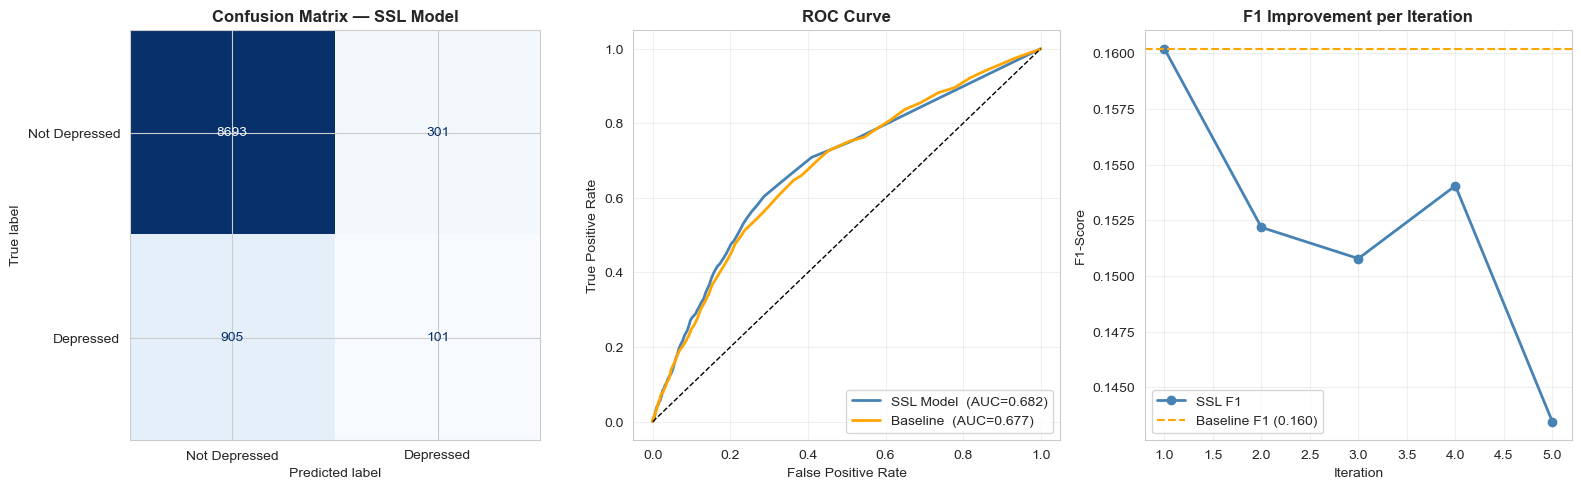

In [73]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, f1_score, precision_score, recall_score
)

y_pred_ssl  = ssl_model.predict(X_test_scaled)
y_proba_ssl = ssl_model.predict_proba(X_test_scaled)[:, 1]

f1_ssl  = f1_score(y_test, y_pred_ssl)
auc_ssl = roc_auc_score(y_test, y_proba_ssl)

print("=" * 65)
print("FINAL SSL MODEL — TEST SET EVALUATION")
print("=" * 65)
print(f"\n  F1-Score  : {f1_ssl:.4f}")
print(f"  ROC-AUC   : {auc_ssl:.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_ssl):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_ssl):.4f}")
print("\nDetailed Classification Report:")
print("-" * 65)
print(classification_report(y_test, y_pred_ssl,
                             target_names=["Not Depressed", "Depressed"]))



fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0])
cm  = confusion_matrix(y_test, y_pred_ssl)
ConfusionMatrixDisplay(cm, display_labels=["Not Depressed", "Depressed"]).plot(
    ax=ax1, colorbar=False, cmap='Blues'
)
ax1.set_title("Confusion Matrix — SSL Model", fontweight='bold')

# 2. ROC Curve — SSL vs Baseline
ax2 = fig.add_subplot(gs[1])
for label, y_p, auc_val, color in [
    ("SSL Model",  y_proba_ssl,  auc_ssl,  'steelblue'),
    ("Baseline",   y_proba_base, roc_auc_score(y_test, y_proba_base), 'orange'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_p)
    ax2.plot(fpr, tpr, label=f"{label}  (AUC={auc_val:.3f})", color=color, lw=2)
ax2.plot([0,1],[0,1],'k--', lw=1)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve", fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# 3. F1 Progress across self-training iterations
ax3 = fig.add_subplot(gs[2])
iterations = [h['iteration'] for h in history]
f1_scores  = [h['f1']       for h in history]
ax3.plot(iterations, f1_scores, marker='o', color='steelblue', lw=2, label='SSL F1')
ax3.axhline(f1_base, color='orange', linestyle='--', lw=1.5, label=f'Baseline F1 ({f1_base:.3f})')
ax3.set_xlabel("Iteration")
ax3.set_ylabel("F1-Score")
ax3.set_title("F1 Improvement per Iteration", fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ssl_evaluation.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: ssl_evaluation.png")
plt.show()


## Step 8: Compare SSL vs Supervised-Only Baseline

MODEL COMPARISON — SSL vs SUPERVISED BASELINE
                            Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                     
Baseline (supervised only)    0.8721     0.2360  0.1213    0.1602   0.6766
SSL (self-training)           0.8794     0.2512  0.1004    0.1435   0.6819

Improvement (SSL − Baseline):
-----------------------------------------------------------------
  Accuracy    : ▲ 0.0073
  Precision   : ▲ 0.0153
  Recall      : ▼ 0.0209
  F1-Score    : ▼ 0.0167
  ROC-AUC     : ▲ 0.0052

✓ Saved: model_comparison.png


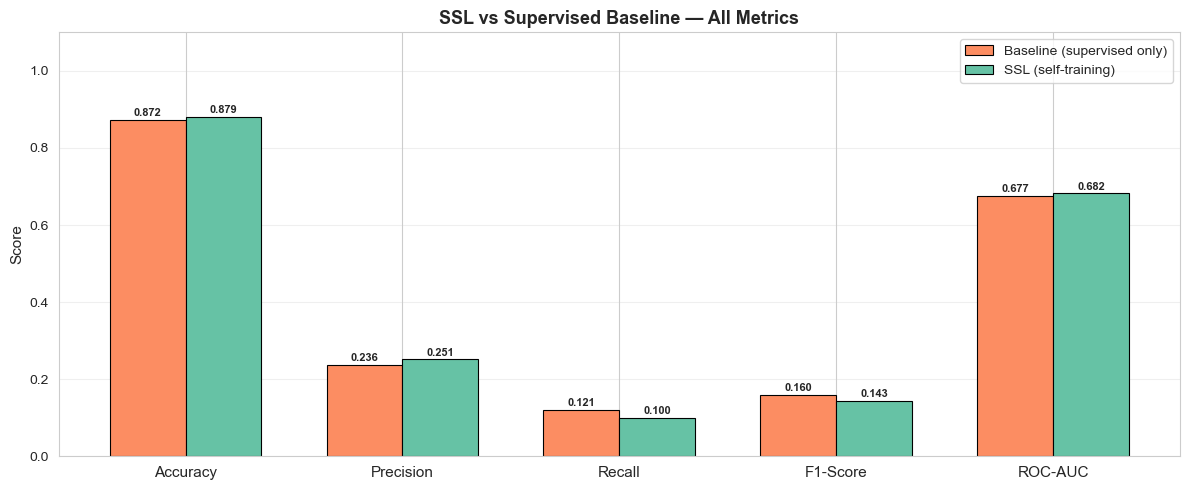

In [74]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Baseline (supervised only)": (y_pred_base, y_proba_base),
    "SSL (self-training)":        (y_pred_ssl,  y_proba_ssl),
}

rows = []
for name, (y_pred, y_proba) in models.items():
    rows.append({
        "Model"    : name,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1-Score" : f1_score(y_test, y_pred),
        "ROC-AUC"  : roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(rows).set_index("Model")

# ── Print comparison table ────────────────────────────────────────────────────
print("=" * 65)
print("MODEL COMPARISON — SSL vs SUPERVISED BASELINE")
print("=" * 65)
print(results_df.to_string(float_format="{:.4f}".format))

# ── Delta row ────────────────────────────────────────────────────────────────
delta = results_df.loc["SSL (self-training)"] - results_df.loc["Baseline (supervised only)"]
print("\nImprovement (SSL − Baseline):")
print("-" * 65)
for metric, val in delta.items():
    arrow = "▲" if val > 0 else "▼"
    print(f"  {metric:<12}: {arrow} {abs(val):.4f}")

# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x        = range(len(metrics))
width    = 0.35
colors   = ['#fc8d62', '#66c2a5']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(results_df.index, colors)):
    vals = [results_df.loc[name, m] for m in metrics]
    bars = ax.bar([xi + i*width for xi in x], vals, width, label=name,
                  color=color, edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks([xi + width/2 for xi in x])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("SSL vs Supervised Baseline — All Metrics", fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison.png")
plt.show()




## Phase 4 — Explainability with SHAP

## Step 9: Global Feature Importance (SHAP)

SHAP -- GLOBAL FEATURE IMPORTANCE
               Feature  Mean |SHAP|
                  CGPA     0.178319
          Stress_Level     0.101496
                   Age     0.065752
        Sleep_Duration     0.051821
           Study_Hours     0.039895
     Physical_Activity     0.037546
    Social_Media_Hours     0.037035
                Gender     0.011061
    Department_Science     0.006634
   Department_Business     0.006552
    Department_Medical     0.005784
Department_Engineering     0.005682
Saved: shap_global_importance.png


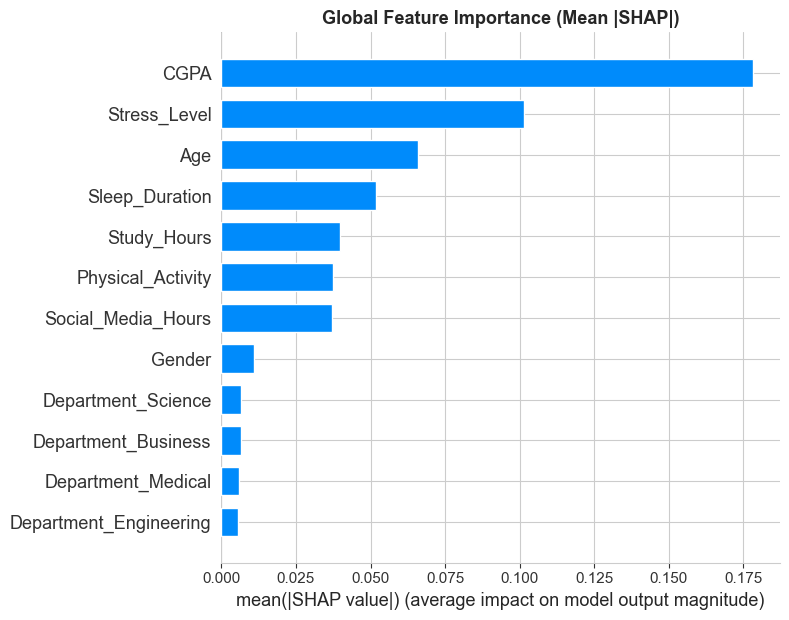

Saved: shap_beeswarm.png


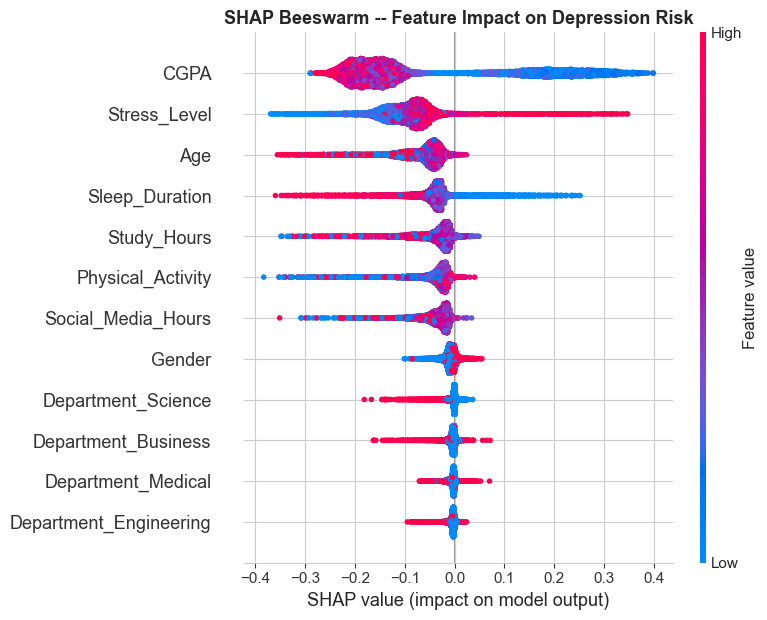

In [75]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Build SHAP explainer on the final SSL model
explainer   = shap.TreeExplainer(ssl_model)
shap_values = explainer.shap_values(X_test_scaled)

# Handle both old SHAP (list) and new SHAP (3-D array) APIs
if isinstance(shap_values, list):
    shap_dep = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_dep = shap_values[:, :, 1]
else:
    shap_dep = shap_values

feature_names = X.columns.tolist()

print("=" * 60)
print("SHAP -- GLOBAL FEATURE IMPORTANCE")
print("=" * 60)

# Mean absolute SHAP value per feature
mean_shap = np.abs(shap_dep).mean(axis=0)
importance_df = (
    pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": mean_shap})
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.to_string(index=False))

# Plot 1: Bar summary (global importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_dep, X_test_scaled, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean |SHAP|)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=300, bbox_inches="tight")
print("Saved: shap_global_importance.png")
plt.show()

# Plot 2: Beeswarm (direction + magnitude per student)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_dep, X_test_scaled, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm -- Feature Impact on Depression Risk",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight")
print("Saved: shap_beeswarm.png")
plt.show()



## Step 10: Individual Student Explanation (SHAP Force Plot)

STEP 10 -- INDIVIDUAL SHAP EXPLANATIONS

AT-RISK STUDENT (test index 52)
  Actual    : Depressed
  Predicted : Depressed
  Risk prob : 0.5700
  Top 5 contributing features:
    CGPA                     : SHAP=+0.3279  (increases depression risk)
    Stress_Level             : SHAP=-0.1053  (decreases depression risk)
    Social_Media_Hours       : SHAP=-0.0602  (decreases depression risk)
    Age                      : SHAP=-0.0402  (decreases depression risk)
    Sleep_Duration           : SHAP=-0.0278  (decreases depression risk)

LOW-RISK STUDENT (test index 0)
  Actual    : Not Depressed
  Predicted : Not Depressed
  Risk prob : 0.0100
  Top 5 contributing features:
    CGPA                     : SHAP=-0.1555  (decreases depression risk)
    Stress_Level             : SHAP=-0.0864  (decreases depression risk)
    Study_Hours              : SHAP=-0.0727  (decreases depression risk)
    Age                      : SHAP=-0.0572  (decreases depression risk)
    Sleep_Duration           

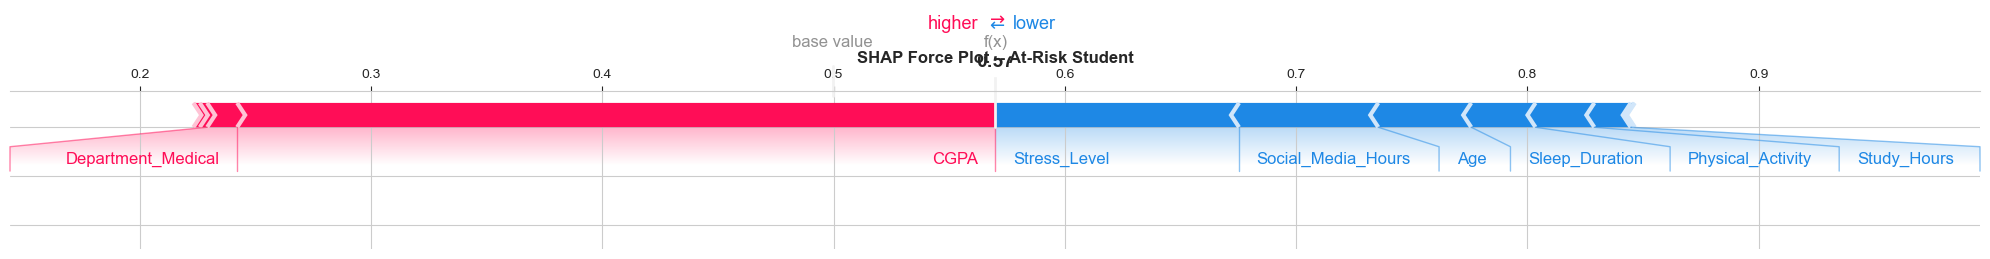

Saved: shap_force_low_risk.png


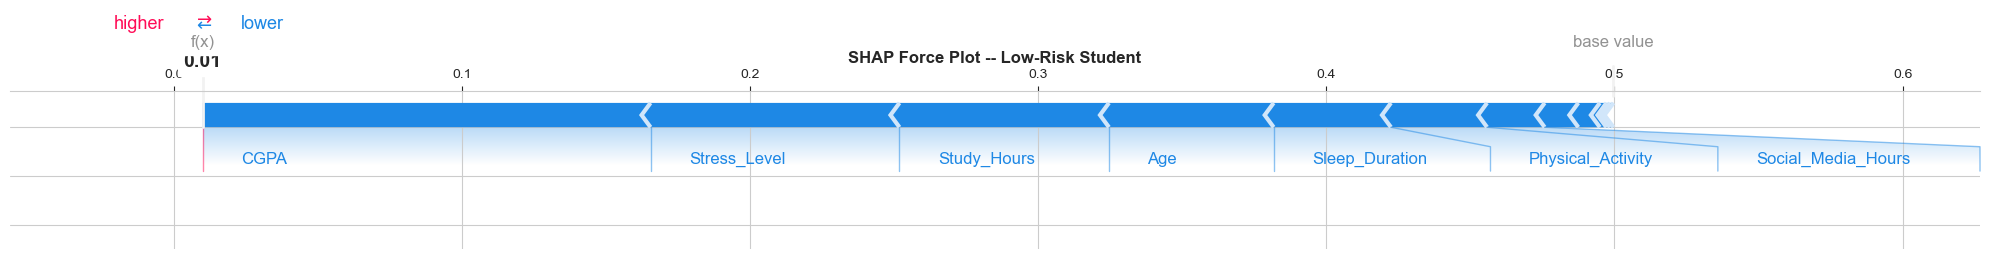

Saved: shap_waterfall_at_risk.png


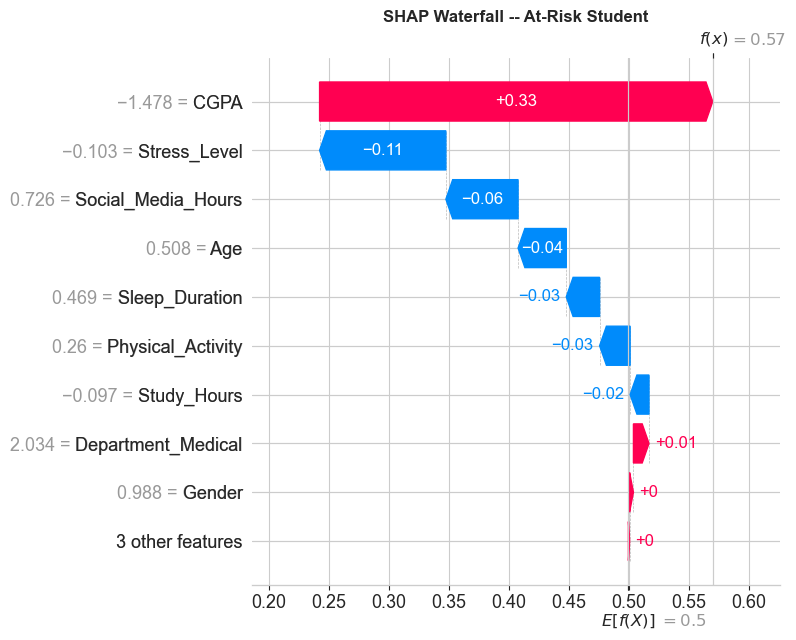

Saved: shap_waterfall_low_risk.png


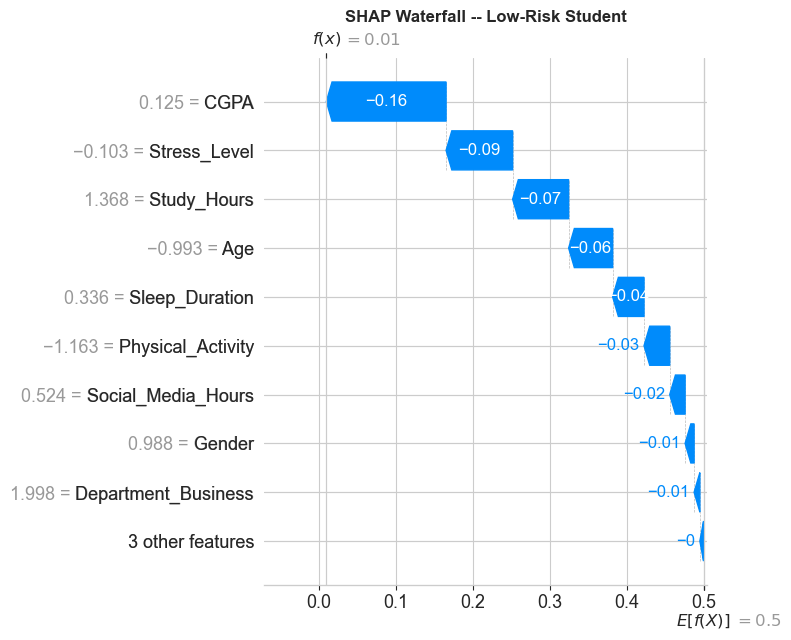

In [76]:
import shap
import numpy as np
import matplotlib.pyplot as plt

at_risk_idx  = np.where(y_pred_ssl == 1)[0][0]
low_risk_idx = np.where(y_pred_ssl == 0)[0][0]

# Handle both old (list/array) and new (scalar) expected_value APIs
exp_val = (explainer.expected_value[1]
           if isinstance(explainer.expected_value, (list, np.ndarray))
           else explainer.expected_value)

print("=" * 65)
print("STEP 10 -- INDIVIDUAL SHAP EXPLANATIONS")
print("=" * 65)

for label, idx in [("AT-RISK STUDENT", at_risk_idx), ("LOW-RISK STUDENT", low_risk_idx)]:
    actual    = "Depressed" if y_test.iloc[idx] == 1 else "Not Depressed"
    predicted = "Depressed" if y_pred_ssl[idx] == 1 else "Not Depressed"
    prob      = y_proba_ssl[idx]
    print()
    print(f"{label} (test index {idx})")
    print(f"  Actual    : {actual}")
    print(f"  Predicted : {predicted}")
    print(f"  Risk prob : {prob:.4f}")
    student_shap = shap_dep[idx]
    contrib = sorted(zip(X.columns, student_shap), key=lambda x: abs(x[1]), reverse=True)
    print("  Top 5 contributing features:")
    for feat, val in contrib[:5]:
        direction = "increases" if val > 0 else "decreases"
        print(f"    {feat:<25}: SHAP={val:+.4f}  ({direction} depression risk)")

# Force plots
print()
print("Generating force plots...")
for label, idx, fname in [
    ("At-Risk Student",  at_risk_idx,  "shap_force_at_risk.png"),
    ("Low-Risk Student", low_risk_idx, "shap_force_low_risk.png"),
]:
    shap.force_plot(exp_val, shap_dep[idx], X.columns.tolist(),
                    matplotlib=True, show=False)
    plt.title(f"SHAP Force Plot -- {label}", fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show()

# Waterfall plots
for label, idx, fname in [
    ("At-Risk Student",  at_risk_idx,  "shap_waterfall_at_risk.png"),
    ("Low-Risk Student", low_risk_idx, "shap_waterfall_low_risk.png"),
]:
    explanation = shap.Explanation(
        values        = shap_dep[idx],
        base_values   = exp_val,
        data          = X_test_scaled[idx],
        feature_names = X.columns.tolist()
    )
    plt.figure()
    shap.waterfall_plot(explanation, show=False)
    plt.title(f"SHAP Waterfall -- {label}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show()



## Phase 5 — Gender-Aware Analysis

## Step 11: Gender-Stratified Results

STEP 11 -- GENDER-STRATIFIED EVALUATION

           N  Depressed  Dep %  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gender                                                                        
Male    5043        522   10.4    0.8721     0.2383  0.1073    0.1480   0.6835
Female  4957        484    9.8    0.8868     0.2695  0.0930    0.1382   0.6792

Gap (Male - Female):
----------------------------------------
  F1-Score    : up 0.0098
  Recall      : up 0.0143
  Precision   : down 0.0312
  ROC-AUC     : up 0.0043

Saved: gender_stratified_analysis.png


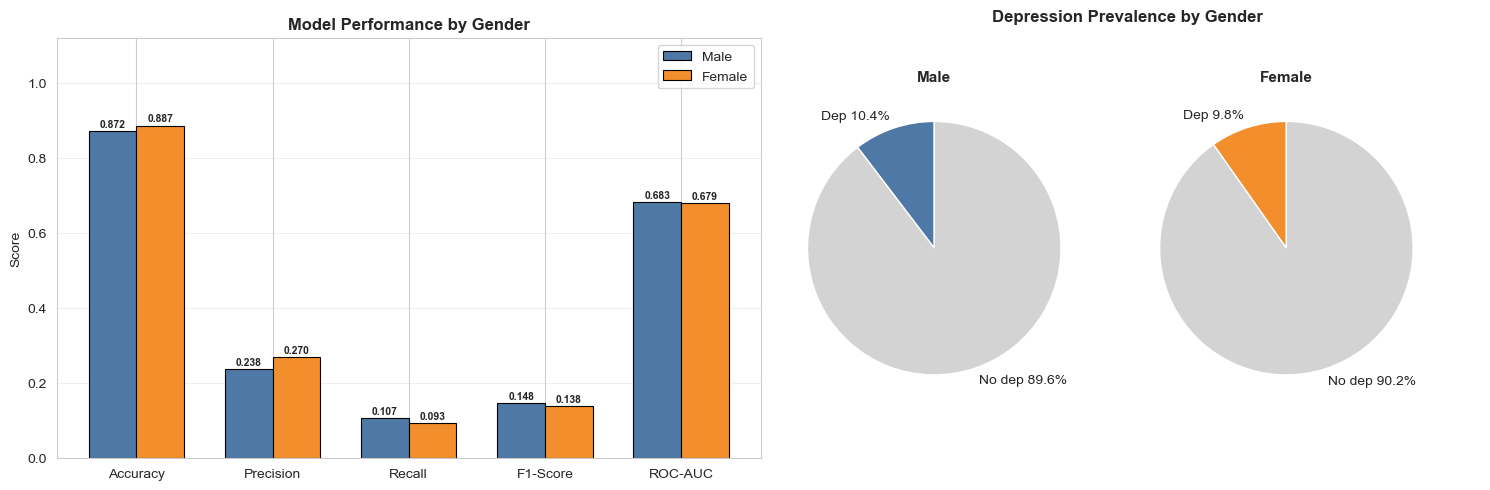

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, accuracy_score)

gender_test = df_model.loc[X_test.index, "Gender"]

print("=" * 65)
print("STEP 11 -- GENDER-STRATIFIED EVALUATION")
print("=" * 65)

rows = []
for gender_val, gender_label in [(1, "Male"), (0, "Female")]:
    mask     = (gender_test == gender_val).values
    y_true_g = y_test.values[mask]
    y_pred_g = y_pred_ssl[mask]
    y_prob_g = y_proba_ssl[mask]
    n_total  = mask.sum()
    n_dep    = y_true_g.sum()
    rows.append({
        "Gender"    : gender_label,
        "N"         : n_total,
        "Depressed" : n_dep,
        "Dep %"     : round(n_dep / n_total * 100, 1),
        "Accuracy"  : round(accuracy_score(y_true_g, y_pred_g), 4),
        "Precision" : round(precision_score(y_true_g, y_pred_g, zero_division=0), 4),
        "Recall"    : round(recall_score(y_true_g, y_pred_g, zero_division=0), 4),
        "F1-Score"  : round(f1_score(y_true_g, y_pred_g, zero_division=0), 4),
        "ROC-AUC"   : round(roc_auc_score(y_true_g, y_prob_g), 4),
    })

gender_df = pd.DataFrame(rows).set_index("Gender")
print()
print(gender_df.to_string())

# Delta between genders
metric_cols = ["F1-Score", "Recall", "Precision", "ROC-AUC"]
delta = (gender_df.loc["Male", metric_cols]
         - gender_df.loc["Female", metric_cols])
print()
print("Gap (Male - Female):")
print("-" * 40)
for metric, val in delta.items():
    arrow = "up" if val > 0 else "down"
    print(f"  {metric:<12}: {arrow} {abs(val):.4f}")

# Plots
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x       = np.arange(len(metrics))
width   = 0.35
colors  = ["#4e79a7", "#f28e2b"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar chart
for i, (gender, color) in enumerate(zip(["Male", "Female"], colors)):
    vals = [gender_df.loc[gender, m] for m in metrics]
    bars = axes[0].bar(x + i*width, vals, width, label=gender,
                       color=color, edgecolor="black", linewidth=0.8)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", va="bottom",
                     fontsize=7.5, fontweight="bold")

axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylabel("Score")
axes[0].set_title("Model Performance by Gender", fontweight="bold", fontsize=12)
axes[0].set_ylim(0, 1.12)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Side-by-side pie charts for depression prevalence
for i, (gender, color) in enumerate(zip(["Male", "Female"], colors)):
    ax_pie = axes[1].inset_axes([i * 0.5, 0, 0.45, 1])
    n_dep   = int(gender_df.loc[gender, "Depressed"])
    n_total = int(gender_df.loc[gender, "N"])
    n_nodep = n_total - n_dep
    ax_pie.pie(
        [n_dep, n_nodep],
        labels=[f"Dep {n_dep/n_total*100:.1f}%", f"No dep {n_nodep/n_total*100:.1f}%"],
        colors=[color, "#d3d3d3"],
        startangle=90,
        wedgeprops={"edgecolor": "white"}
    )
    ax_pie.set_title(gender, fontweight="bold", fontsize=11)

axes[1].axis("off")
axes[1].set_title("Depression Prevalence by Gender", fontweight="bold", fontsize=12, y=1.02)

plt.tight_layout()
plt.savefig("gender_stratified_analysis.png", dpi=300, bbox_inches="tight")
print()
print("Saved: gender_stratified_analysis.png")
plt.show()
